# Compare PIL-APS vs DPMAC
Notebook này đọc metrics từ thư mục `experiments/` và vẽ plot vào `plots/`.

In [3]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

ROOT = Path.cwd()
EXP = ROOT / 'experiments'
PLOTS = ROOT / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

def load_metrics(preferred_name, fallback_name=None):
    p = EXP / preferred_name
    if p.exists():
        return json.loads(p.read_text())
    if fallback_name is not None:
        q = EXP / fallback_name
        if q.exists():
            return json.loads(q.read_text())
    raise FileNotFoundError(f'Cannot find {preferred_name} (or fallback {fallback_name}) in {EXP}')

pil_hist = load_metrics('pil_aps_metrics_compare.json', 'pil_aps_metrics.json')
dpmac_hist = load_metrics('dpmac_metrics_compare.json', 'dpmac_metrics.json')

print(f'Loaded PIL points: {len(pil_hist)}')
print(f'Loaded DPMAC points: {len(dpmac_hist)}')

Loaded PIL points: 300
Loaded DPMAC points: 300


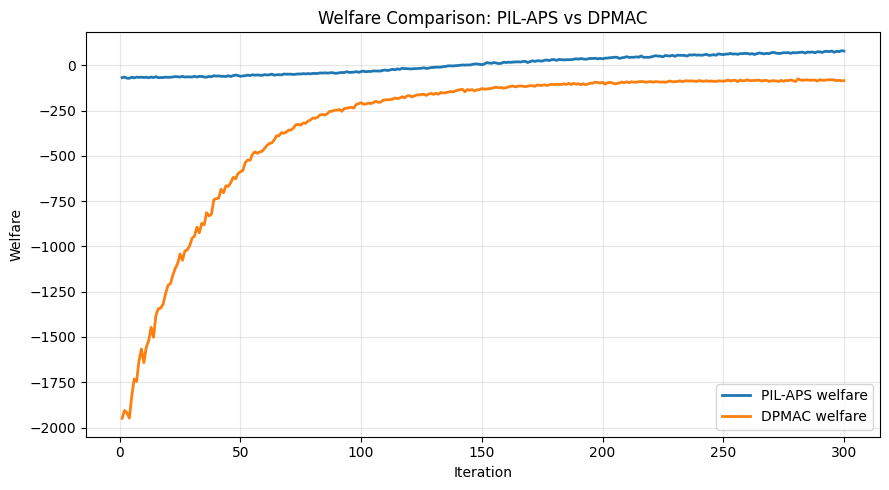

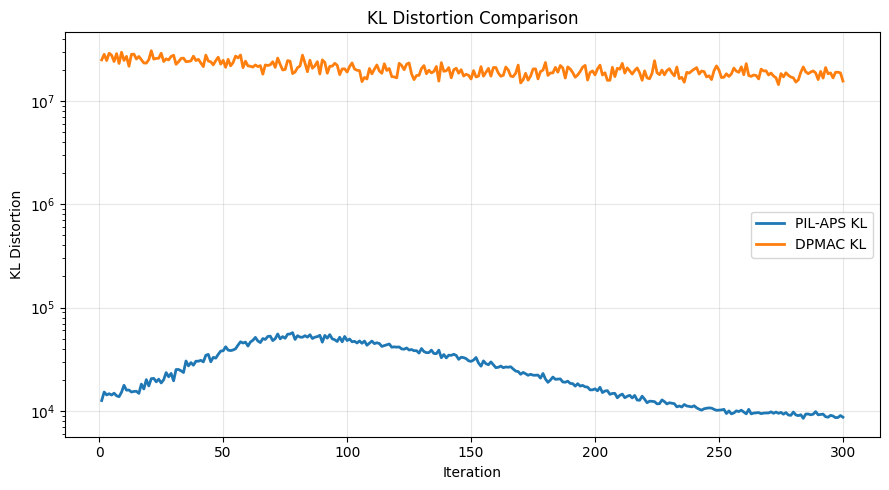

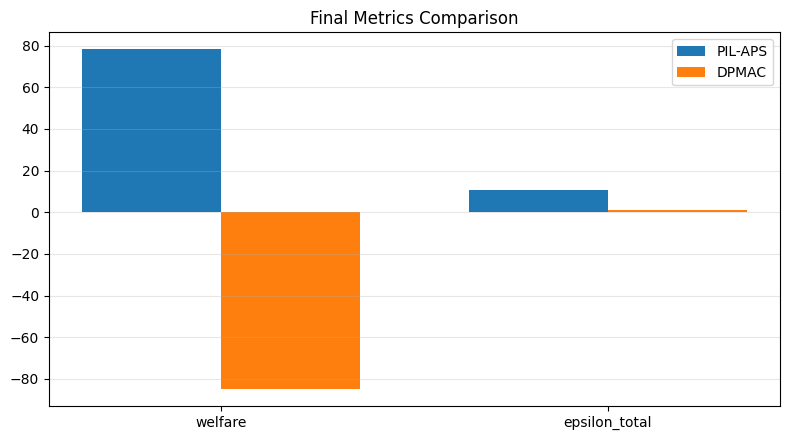

Saved plots to: /home/khanh/Khanh_stuff/PIL/plots


In [4]:
def series(hist, key):
    return [row.get(key, None) for row in hist]

x_pil = series(pil_hist, 'iteration')
x_dpmac = series(dpmac_hist, 'iteration')

# 1) Welfare curve
plt.figure(figsize=(9, 5))
plt.plot(x_pil, series(pil_hist, 'welfare'), label='PIL-APS welfare', linewidth=2)
plt.plot(x_dpmac, series(dpmac_hist, 'welfare'), label='DPMAC welfare', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Welfare')
plt.title('Welfare Comparison: PIL-APS vs DPMAC')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'welfare_compare.png', dpi=160)
plt.show()

# 2) KL distortion curve
plt.figure(figsize=(9, 5))
plt.plot(x_pil, series(pil_hist, 'kl'), label='PIL-APS KL', linewidth=2)
plt.plot(x_dpmac, series(dpmac_hist, 'kl'), label='DPMAC KL', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('KL Distortion')
plt.title('KL Distortion Comparison')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'kl_compare.png', dpi=160)
plt.show()

# 3) Final metric bar chart
pil_last = pil_hist[-1]
dpmac_last = dpmac_hist[-1]
labels = ['welfare', 'epsilon_total']
pil_vals = [pil_last.get('welfare', 0.0), pil_last.get('epsilon_total', 0.0)]
dpmac_vals = [dpmac_last.get('welfare', 0.0), dpmac_last.get('epsilon_total', 0.0)]

x = range(len(labels))
w = 0.36
plt.figure(figsize=(8, 4.5))
plt.bar([i - w/2 for i in x], pil_vals, width=w, label='PIL-APS')
plt.bar([i + w/2 for i in x], dpmac_vals, width=w, label='DPMAC')
plt.xticks(list(x), labels)
plt.title('Final Metrics Comparison')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'final_metrics_compare.png', dpi=160)
plt.show()

print('Saved plots to:', PLOTS.resolve())